# STEP 1: MACHINE LEARNING MODELS
#### *`Data: Jigsaw Toxic Comment Classification`*

### 1.1 IMPORT LIBRARIES

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 1.2 LOAD DATASET


In [12]:
df = pd.read_csv('/content/train.csv', engine='python', on_bad_lines='skip')
df = df[['comment_text', 'toxic']].copy()
df = df.sample(n=10_000, random_state=42).reset_index(drop=True)

df.shape

(10000, 2)

> The dataset has 8 columns, but i only need 2.
> `comment_text` is our input and `toxic` is our target.
> The remaining 6 columns are for multi-label classification — outside the scope of this project.

In [13]:
df.head()

,comment_text,toxic
0,"Geez, are you forgetful! We've already discus...",0
1,Carioca RFA \n\nThanks for your support on my ...,0
2,"""\n\n Birthday \n\nNo worries, It's what I do ...",0
3,Pseudoscience category? \n\nI'm assuming that ...,0
4,"(and if such phrase exists, it would be provid...",0


In [14]:
df.columns

Index(['comment_text', 'toxic'], dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   comment_text  10000 non-null  object
 1   toxic         10000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 156.4+ KB


In [16]:
df.isnull().sum()

,0
comment_text,0
toxic,0


> The dataset is imbalanced — 90.58% Safe and 9.42% Toxic. Therefore, I will use **F1-Score** as my main metric.

toxic
0    9058
1     942
Name: count, dtype: int64


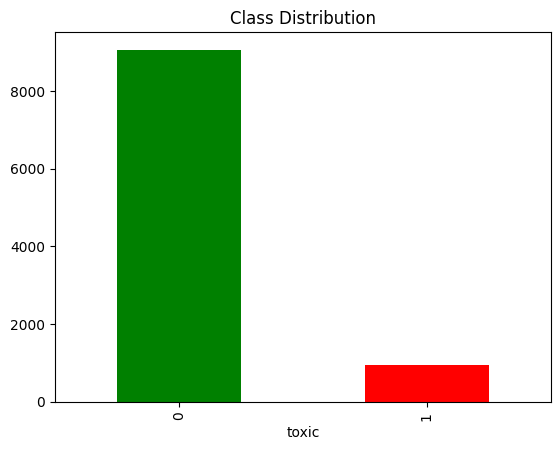

In [17]:
print(df['toxic'].value_counts())

df['toxic'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Class Distribution')
plt.show()

In [18]:
stop_words = set(stopwords.words('english'))

def clean(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['comment_text'].apply(clean)

In [19]:
df['comment_text'].head(10)

,comment_text
0,"Geez, are you forgetful! We've already discus..."
1,Carioca RFA \n\nThanks for your support on my ...
2,"""\n\n Birthday \n\nNo worries, It's what I do ..."
3,Pseudoscience category? \n\nI'm assuming that ...
4,"(and if such phrase exists, it would be provid..."
5,", 9 October 2007 (UTC)\n\nP.s, the delta funct..."
6,"]]- 10 September 1910, [[[Couvet]] )"
7,Negro league baseball task-force talk].
8,List of My Three Sons episodes \n\nI saw you r...
9,Quoting Loremaster: In order to make sure you ...


In [20]:
X = df['clean_text']
y = df['toxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(X_train)
X_test  = tfidf.transform(X_test)


Logistic Regression
              precision    recall  f1-score   support

        Safe       0.97      0.95      0.96      1812
       Toxic       0.61      0.70      0.65       188

    accuracy                           0.93      2000
   macro avg       0.79      0.82      0.80      2000
weighted avg       0.93      0.93      0.93      2000



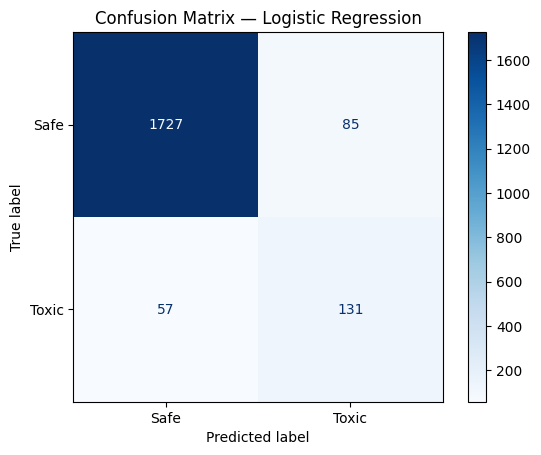


Random Forest
              precision    recall  f1-score   support

        Safe       0.94      0.97      0.96      1812
       Toxic       0.59      0.43      0.50       188

    accuracy                           0.92      2000
   macro avg       0.77      0.70      0.73      2000
weighted avg       0.91      0.92      0.91      2000



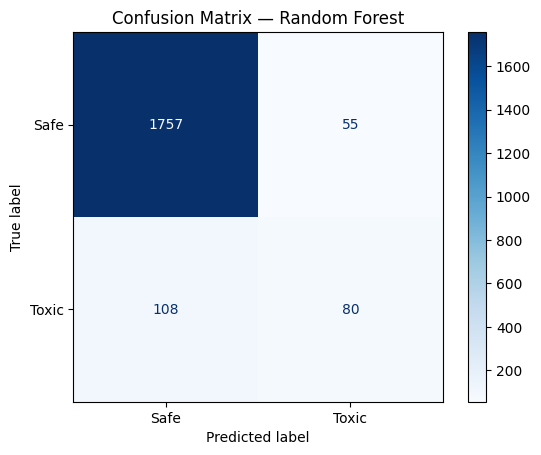


Decision Tree
              precision    recall  f1-score   support

        Safe       0.94      0.98      0.96      1812
       Toxic       0.67      0.38      0.49       188

    accuracy                           0.92      2000
   macro avg       0.80      0.68      0.72      2000
weighted avg       0.91      0.92      0.91      2000



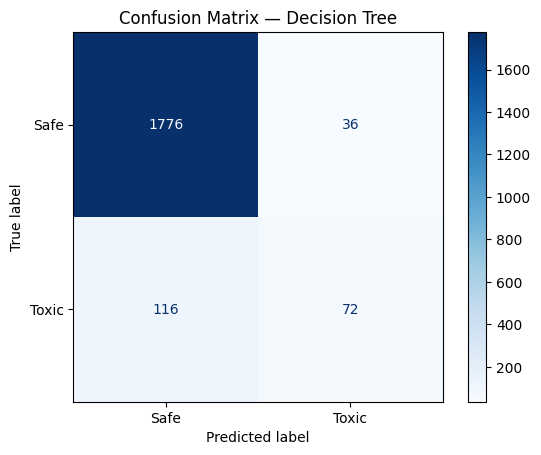

In [21]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results = [r for r in results if r['Model'] != name]
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_test, y_pred, zero_division=0), 4)
    })

    print(f'\n{name}')
    print(classification_report(y_test, y_pred, target_names=['Safe', 'Toxic']))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Toxic']).plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.show()

> **Best Model: Logistic Regression**
> - Toxic F1-Score: **0.65** (highest among all models)
> - Random Forest: 0.50
> - Decision Tree: 0.49

# STEP 2: NEURAL NETWORK

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [23]:
X_train = X_train.toarray()
X_test  = X_test.toarray()

In [24]:
model = Sequential([
    Dense(32, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.6),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8977 - loss: 0.4363 - val_accuracy: 0.8994 - val_loss: 0.2941
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9084 - loss: 0.2659 - val_accuracy: 0.9056 - val_loss: 0.2550
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9214 - loss: 0.2190 - val_accuracy: 0.9206 - val_loss: 0.2224
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9380 - loss: 0.1772 - val_accuracy: 0.9344 - val_loss: 0.2025
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9489 - loss: 0.1477 - val_accuracy: 0.9375 - val_loss: 0.1950
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9584 - loss: 0.1234 - val_accuracy: 0.9362 - val_loss: 0.1910
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9639 - loss: 0.1081 - val_accuracy: 0.9369 - val_loss: 0.1937
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9694 - loss: 0.0928 - val_accuracy: 0.

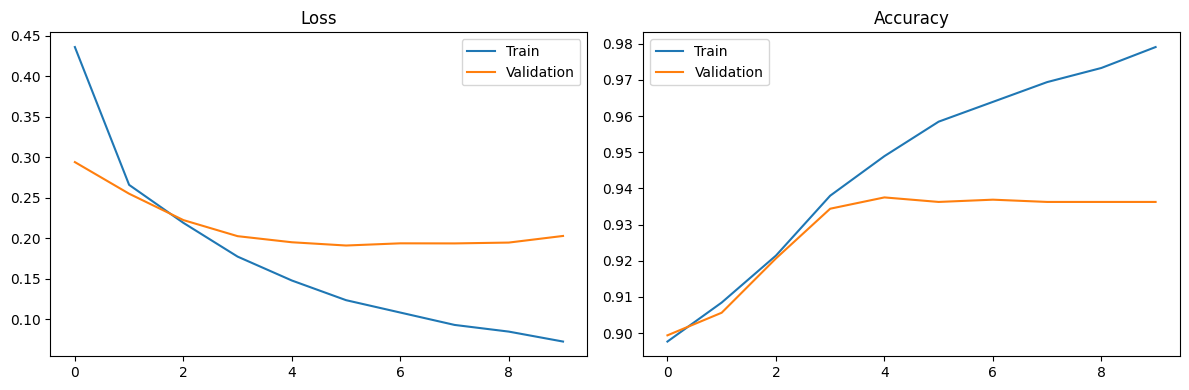

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

        Safe       0.95      0.99      0.97      1812
       Toxic       0.82      0.48      0.60       188

    accuracy                           0.94      2000
   macro avg       0.88      0.73      0.79      2000
weighted avg       0.94      0.94      0.93      2000



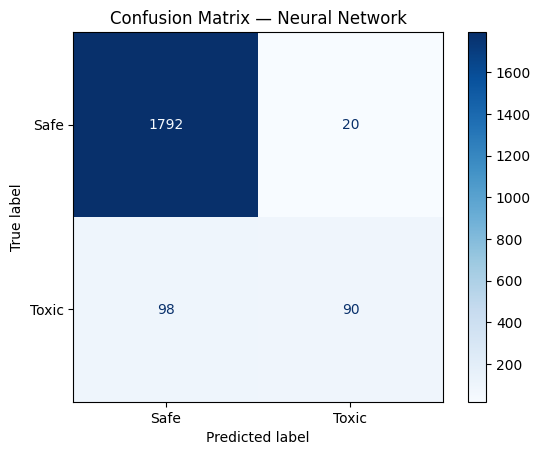

In [28]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Safe', 'Toxic']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Toxic']).plot(cmap='Blues')
plt.title('Confusion Matrix — Neural Network')
plt.show()

In [29]:
results.append({
    'Model'    : 'Neural Network',
    'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
    'F1-Score' : round(f1_score(y_test, y_pred, zero_division=0), 4)
})

summary = pd.DataFrame(results)
print(summary.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9290     0.6065  0.6968    0.6485
      Random Forest    0.9185     0.5926  0.4255    0.4954
      Decision Tree    0.9240     0.6667  0.3830    0.4865
     Neural Network    0.9410     0.8182  0.4787    0.6040


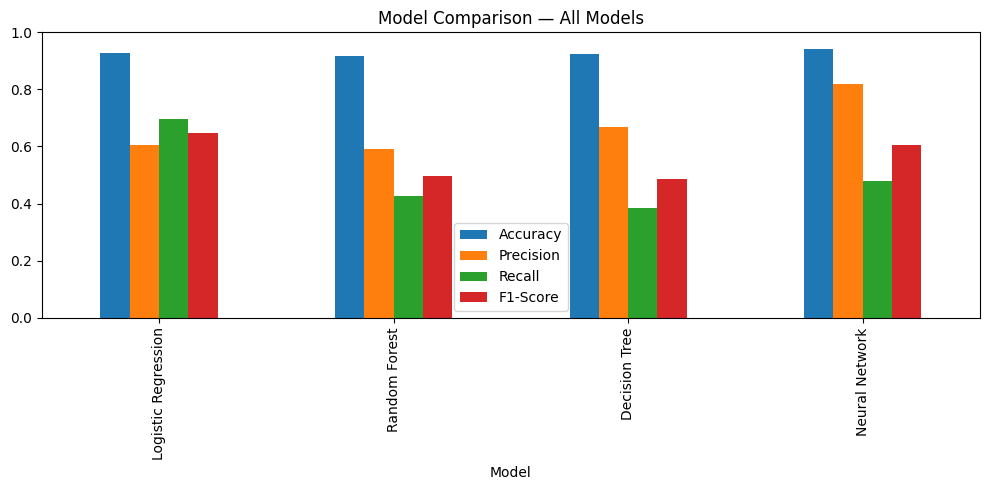

In [30]:
summary.plot(x='Model', kind='bar', figsize=(10, 5))
plt.title('Model Comparison — All Models')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

> The Neural Network achieved a higher Precision (0.81) but lower Recall (0.47), giving an F1-Score of 0.60.

> Logistic Regression remains the best model with F1 of 0.65 and better Recall for catching toxic comments.

> Therefore, the Neural Network was not better than Logistic Regression for this dataset.

In [31]:
!pip install gradio

import gradio as gr

def predict(comment):
    cleaned = clean(comment)
    vectorized = tfidf.transform([cleaned])
    vectorized = vectorized.toarray()
    prob = model.predict(vectorized)[0][0]
    label = "🚨 Toxic" if prob > 0.3 else "✅ Safe"
    confidence = f"{prob*100:.1f}%" if prob > 0.3 else f"{(1-prob)*100:.1f}%"
    return f"{label} — Confidence: {confidence}"

gr.Interface(
    fn=predict,
    inputs=gr.Textbox(label="Enter a comment"),
    outputs=gr.Textbox(label="Result"),
    title="Toxic Comment Classifier"
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ebc5963451c1ed1c93.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
